# Motion Blur Analysis

Quantifies the effect of translational motion blur on localisation precision and colour precision
using the elliptical S3M fitting pipeline (`FittingStrategy.ELLIPTICAL`).

**Motion model:** constant velocity in a random direction during a 100 ms frame exposure.
Per-frame displacement = velocity × 0.1 s.  Each frame gets an independent random direction.

**Structure**
1. PSF shape visualisation — Gaussian PSF at increasing motion blur displacement
2. Velocity sweep simulation — N velocities × 3 photon levels × 3 dyes
3. Analysis — localisation precision, colour precision, and PSF ellipticity vs velocity

In [1]:
import sys, os, glob, types
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import polars as pl


sys.path.append(str(Path(os.getcwd()).parent.parent.parent))

from src import IOFunctions, SpectralFunctions, MaskFunctions, sCMOSFunctions, PlottingBase
from src.Multicolour_Simulation_Functions import (
    FittingStrategy, SimulationConfig, MultiC_Sim_Funcs,
)

IO    = IOFunctions.IO_Functions()
S_F   = SpectralFunctions.Spectral_Funcs()
M_F   = MaskFunctions.Mask_Functions()
sCMOS = sCMOSFunctions.sCMOS_Functions()
MSF   = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter()

In [2]:
# ── Camera calibration ────────────────────────────────────────────────────────
cal_folder = Path("../../../Camera_Calibrations/Ximea_Camera/")
gain      = IO.read_tiff(str(cal_folder / "gain.tif"))
offset    = IO.read_tiff(str(cal_folder / "offset.tif"))
variance  = IO.read_tiff(str(cal_folder / "variance.tif"))
readnoise = float(np.median(IO.read_tiff(str(cal_folder / "readnoise.tif"))))
rqe       = IO.read_tiff(str(cal_folder / "rqe.tif"))

print(f"Camera calibration loaded — sensor: {gain.shape}, readnoise: {readnoise:.2f}")

Camera calibration loaded — sensor: (1544, 2064), readnoise: 2.34


In [3]:
# ── Spectral setup ────────────────────────────────────────────────────────────
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])   # (3, n_wl); convention B=0, G=1, R=2

dyes          = ["ATTO 488", "ATTO 565", "ATTO 647N"]
filters       = []
NA            = 1.49
pixel_size_nm = 69.0        # Ximea object-space pixel (nm)
image_dims    = 22          # 22 × 22 px
background_photons = 5.0
frame_exposure_ms  = 100.0  # fixed 50 ms frame exposure

smoothing_function = types.SimpleNamespace(
    args={"sigma": 1.5},
    extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack,
    data_arg="image",
)

print(f"Wavelength grid: {wavelength[0]:.0f}–{wavelength[-1]:.0f} nm  ({len(wavelength)} pts)")

Wavelength grid: 400–999 nm  (600 pts)


In [4]:
# ── Save folder ───────────────────────────────────────────────────────────────
save_folder = Path("/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur")
save_folder.mkdir(parents=True, exist_ok=True)
print(f"Results → {save_folder}")

Results → /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur


## Figure 1: PSF shape under motion blur

Time-integrated Gaussian PSF at increasing displacement (velocity × 100 ms exposure).  
No noise, no camera effects — shows the pure effect of the motion blur kernel.

In [5]:
# ── Compute motion-blurred PSFs for visualisation ─────────────────────────────
# Use a fine pixel grid to resolve the Airy disk structure.
from src.simulation.multicolour import MultiC_Sim_Funcs_Refactored

pix_vis_nm  = 10.0          # 10 nm/px oversampling
psf_size_vis = 201          # 2.01 µm window
sigma_vis_nm = 120.0        # approximate Gaussian sigma for a 488 nm dye, NA 1.49

# Displacements to show: 0, 50, 100, 200, 400 nm (= 0, 500, 1000, 2000, 4000 nm/s × 100 ms)
displacements_nm = np.array([0, 100, 250, 500, 1000], dtype=float)
n_disp = len(displacements_nm)

# Build analytic Gaussian PSF callable on a (psf_size_vis × psf_size_vis) grid
_cx = psf_size_vis / 2.0
xx, yy = np.meshgrid(np.arange(psf_size_vis), np.arange(psf_size_vis), indexing="ij")
sigma_px = sigma_vis_nm / pix_vis_nm

def _gauss_fn(x0, y0, _n):
    g = np.exp(-((xx - x0)**2 + (yy - y0)**2) / (2 * sigma_px**2))
    return (g / g.sum()).astype(np.float32)

psf_vis_stack = []
np.random.seed(42)
for d_nm in displacements_nm:
    d_px = d_nm / pix_vis_nm
    if d_px == 0.0:
        psf_vis_stack.append(_gauss_fn(_cx, _cx, None))
    else:
        angle = np.random.uniform(0, 2 * np.pi)  # representative single angle
        psf_vis_stack.append(
            MultiC_Sim_Funcs_Refactored._apply_motion_blur(
                _gauss_fn, np.array([_cx]), np.array([_cx]), np.array([1]),
                d_px, angle, n_samples=51,
            )
        )

print(f"Computed {n_disp} PSF images  (pixel size {pix_vis_nm} nm, σ = {sigma_vis_nm} nm)")

Computed 5 PSF images  (pixel size 10.0 nm, σ = 120.0 nm)


Figure 1 saved.


/tmp/ipykernel_70909/336434421.py:24: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.05)


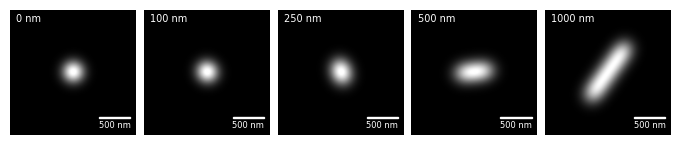

In [6]:
# ── Figure 1: motion-blurred PSF panels ──────────────────────────────────────
fig, axs = plotter.two_column_plot(nrows=1, ncols=n_disp, height=6.69 / n_disp + 0.1)
fs = plotter.config.font_size

for i_d, (d_nm, psf) in enumerate(zip(displacements_nm, psf_vis_stack)):
    I_disp = psf / psf.max()
    plotter.image_plot(
        axs[i_d], I_disp,
        cmap="gray",
        vmin=np.percentile(I_disp, 1), vmax=np.percentile(I_disp, 99.9),
        scalebar=True, pixelsize=pix_vis_nm,
        scalebarsize=500.0, scalebarlabel="500 nm",
        scalebar_color="white", origin="lower",
        colorbar=False,
    )
    label = f"{d_nm:.0f} nm" if d_nm > 0 else "0 nm"
    axs[i_d].text(
        0.05, 0.97, label,
        transform=axs[i_d].transAxes,
        fontsize=fs, color="white", va="top", ha="left",
        bbox=dict(boxstyle="square,pad=0.15", fc="none", ec="none"),
    )

fig.subplots_adjust(wspace=0.05)
#plotter.save_or_show(fig, save_path=str(save_folder / "psf_motion_blur_panels.svg"), show=True)
print("Figure 1 saved.")

ATTO 488      B=0.143  G=0.744  R=0.113
ATTO 565      B=0.028  G=0.389  R=0.583
ATTO 647N     B=0.065  G=0.212  R=0.723
Figure 1b (Bayer detector) saved.


/tmp/ipykernel_70909/3060482345.py:92: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.05, hspace=0.08)


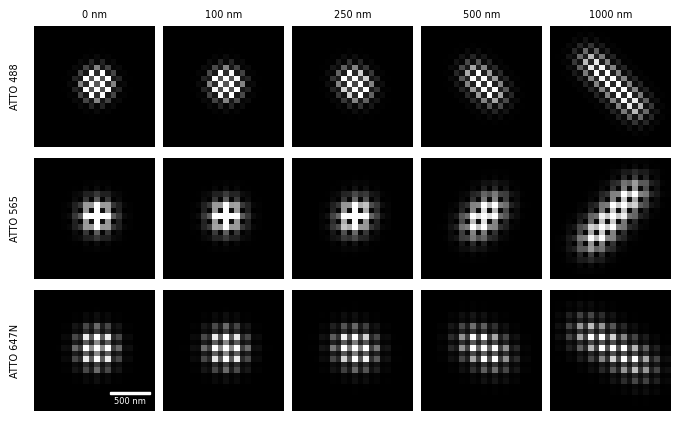

In [7]:
# ── Figure 1b: motion-blur PSFs on the Bayer detector — 3 dyes × 5 displacements ──
# Each detector pixel only receives light through its own Bayer colour filter,
# so the detected image has the characteristic checkerboard brightness pattern.
# The dye-pixel efficiency (DPE) — integral of (emission × channel QY) — sets
# how bright B, G, R pixels are relative to each other for each dye.

# Dye pixel efficiencies: integrate (emission spectrum × per-channel QY) over wavelength
dye_dpe = {}
for dye in dyes:
    dye_spec = S_F.get_dye_or_filter_data(names=[dye], wavelength=wavelength, dye_or_filter=True)[0]
    ch_totals = np.array([
        np.trapz(dye_spec * pixel_QYs[i], wavelength) for i in range(3)  # B=0, G=1, R=2
    ])
    dye_dpe[dye] = ch_totals / ch_totals.sum()
    print(f"{dye:12s}  B={dye_dpe[dye][0]:.3f}  G={dye_dpe[dye][1]:.3f}  R={dye_dpe[dye][2]:.3f}")

# Bayer masks at the actual detector pixel size (image_dims × image_dims)
masks_det = M_F.get_masks(size_x=image_dims, size_y=image_dims)
mask_B = masks_det["B"].astype(float)
mask_G = masks_det["G"].astype(float)
mask_R = masks_det["R"].astype(float)

# PSF grid at detector pixel size (69 nm/px) — each pixel is one Bayer cell
pix_det_nm = pixel_size_nm
_cx_det = image_dims / 2.0
xx_det, yy_det = np.meshgrid(
    np.arange(image_dims), np.arange(image_dims), indexing="ij"
)

# Per-dye Gaussian sigma scales linearly with emission wavelength from 120 nm at 520 nm
dye_emission_nm = {"ATTO 488": 520.0, "ATTO 565": 590.0, "ATTO 647N": 669.0}
dye_sigma_det   = {d: 120.0 * dye_emission_nm[d] / 520.0 for d in dyes}
dye_seeds       = {"ATTO 488": 42, "ATTO 565": 43, "ATTO 647N": 44}

# Build Bayer-weighted PSF stacks (one list-of-images per dye)
bayer_psf_stacks = {}
for dye in dyes:
    sig_px = dye_sigma_det[dye] / pix_det_nm
    np.random.seed(dye_seeds[dye])
    angle = np.random.uniform(0, 2 * np.pi)
    B_frac, G_frac, R_frac = dye_dpe[dye]

    def _gauss_det(x0, y0, _n, _sig=sig_px):
        g = np.exp(-((xx_det - x0) ** 2 + (yy_det - y0) ** 2) / (2 * _sig ** 2))
        return (g / g.sum()).astype(np.float32)

    stack = []
    for d_nm in displacements_nm:
        d_px = d_nm / pix_det_nm
        if d_px == 0.0:
            psf = _gauss_det(_cx_det, _cx_det, None)
        else:
            psf = MultiC_Sim_Funcs_Refactored._apply_motion_blur(
                _gauss_det,
                np.array([_cx_det]), np.array([_cx_det]), np.array([1]),
                d_px, angle, n_samples=51,
            )
        # Each pixel sees only its channel's fraction of the PSF
        bayer_im = psf * (B_frac * mask_B + G_frac * mask_G + R_frac * mask_R)
        stack.append(bayer_im / bayer_im.max() if bayer_im.max() > 0 else bayer_im)
    bayer_psf_stacks[dye] = stack

# ── Plot 3 × n_disp grid ──────────────────────────────────────────────────────
n_rows, n_cols = len(dyes), n_disp
fig, axs = plotter.two_column_plot(
    nrows=n_rows, ncols=n_cols,
    height=n_rows * (6.69 / n_cols) + 0.1,
)

for i_row, dye in enumerate(dyes):
    for i_col, (d_nm, bayer_im) in enumerate(zip(displacements_nm, bayer_psf_stacks[dye])):
        ax = axs[i_row, i_col]
        plotter.image_plot(
            ax, bayer_im,
            cmap="gray",
            interpolation="nearest",
            scalebar=(i_row == n_rows - 1 and i_col == 0),
            pixelsize=pix_det_nm,
            scalebarsize=500.0, scalebarlabel="500 nm",
            scalebar_color="white", origin="lower",
            colorbar=False,
        )
        if i_row == 0:
            ax.set_title(f"{d_nm:.0f} nm" if d_nm > 0 else "0 nm", fontsize=fs)
        if i_col == 0:
            ax.text(
                -0.12, 0.5, dye,
                transform=ax.transAxes,
                fontsize=fs, va="center", ha="right", rotation=90,
            )

fig.subplots_adjust(wspace=0.05, hspace=0.08)
#plotter.save_or_show(
#    fig, save_path=str(save_folder / "psf_motion_blur_bayer_grid.svg"), show=True
#)
print("Figure 1b (Bayer detector) saved.")

## Velocity Sweep Simulation

For each (dye, velocity), run `test_simulation_method` with `FittingStrategy.ELLIPTICAL`
across three photon levels.  The elliptical fitter recovers separate σ_x, σ_y, and θ per localisation,
so the blur-induced PSF elongation is captured directly rather than being averaged into a wider circular σ.

Velocities span 0–10000 nm/s → displacements 0–1000 nm at 100 ms exposure
(0–7.2 pixels at 69 nm/px).

In [8]:
# ── Sweep parameters ─────────────────────────────────────────────────────────
velocities_nm_per_s = np.linspace(0, 10000, 50)
displacements_sweep_nm = velocities_nm_per_s * (frame_exposure_ms / 1000.0)

n_photon_space = np.geomspace(500, 20000, 100)
n_bootstrap    = 10000

print(f"Velocities (nm/s): {velocities_nm_per_s}")
print(f"Displacements (nm): {displacements_sweep_nm}")
print(f"\nSweep: {len(dyes)} dyes × {len(velocities_nm_per_s)} velocities")
print(f"Total simulation calls: {len(dyes) * len(velocities_nm_per_s)}")

Velocities (nm/s): [     0.            204.08163265    408.16326531    612.24489796
    816.32653061   1020.40816327   1224.48979592   1428.57142857
   1632.65306122   1836.73469388   2040.81632653   2244.89795918
   2448.97959184   2653.06122449   2857.14285714   3061.2244898
   3265.30612245   3469.3877551    3673.46938776   3877.55102041
   4081.63265306   4285.71428571   4489.79591837   4693.87755102
   4897.95918367   5102.04081633   5306.12244898   5510.20408163
   5714.28571429   5918.36734694   6122.44897959   6326.53061224
   6530.6122449    6734.69387755   6938.7755102    7142.85714286
   7346.93877551   7551.02040816   7755.10204082   7959.18367347
   8163.26530612   8367.34693878   8571.42857143   8775.51020408
   8979.59183673   9183.67346939   9387.75510204   9591.83673469
   9795.91836735  10000.        ]
Displacements (nm): [    0.            20.40816327    40.81632653    61.2244898     81.63265306
   102.04081633   122.44897959   142.85714286   163.26530612   183.67346

T_frame = 100 ms

    v (nm/s)      d (nm)     D (µm²/s)
--------------------------------------
         204          20       0.00104
        1837         184       0.08434
        3469         347       0.30092
        5102         510       0.65077
        6735         673       1.13390
        8367         837       1.75031
       10000        1000       2.50000


INFO:src.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur/velocity_to_D_conversion.svg


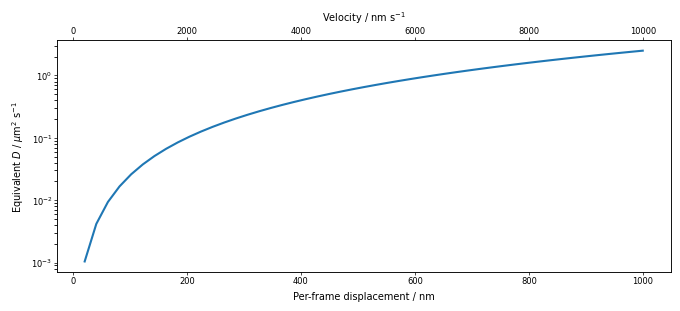

In [9]:
# ── Velocity → effective diffusion coefficient ────────────────────────────────
# The simulation uses constant-velocity motion (speed v, random direction) during
# a frame of exposure time T, giving a fixed per-frame displacement  d = v · T.
#
# A particle undergoing 2D Brownian diffusion with coefficient D has an RMS
# displacement per frame of  sqrt(4 D T).  Setting these equal:
#
#     v · T  =  sqrt(4 D T)   →   D = v² T / 4  =  d² / (4 T)
#
# This is the effective D whose typical per-frame step matches the simulated
# constant-velocity displacement.

T_s = frame_exposure_ms / 1000.0                                # 0.1 s

# Exclude v = 0 (D = 0 is not representable on a log scale)
mask_nz = velocities_nm_per_s > 0
v_nz    = velocities_nm_per_s[mask_nz]
d_nz    = displacements_sweep_nm[mask_nz]
D_nz    = (v_nz ** 2 * T_s / 4) / 1e6                          # µm²/s

print(f"T_frame = {frame_exposure_ms:.0f} ms\n")
print(f"{'v (nm/s)':>12}  {'d (nm)':>10}  {'D (µm²/s)':>12}")
print("-" * 38)
for v, d, D in zip(v_nz[::8], d_nz[::8], D_nz[::8]):
    print(f"{v:12.0f}  {d:10.0f}  {D:12.5f}")

fig, ax = plotter.two_column_plot(nrows=1, ncols=1, height=3.0)

ax.plot(d_nz, D_nz, lw=1.5)
ax.set_xlabel("Per-frame displacement / nm", fontsize=fs)
ax.set_ylabel(r"Equivalent $D$ / $\mu$m$^{2}$ s$^{-1}$", fontsize=fs)
ax.set_yscale("log")
ax.tick_params(labelsize=fs - 1)

# Secondary x-axis showing velocity
ax2 = ax.twiny()
ax2.set_xlim(np.array(ax.get_xlim()) / T_s)
ax2.set_xlabel(r"Velocity / nm s$^{-1}$", fontsize=fs)
ax2.tick_params(labelsize=fs - 1)

plotter.save_or_show(
    fig, save_path=str(save_folder / "velocity_to_D_conversion.svg"), show=True
)

In [10]:
# ── Camera parameters dictionary ──────────────────────────────────────────────
def make_camera_params(image_dims):
    return {
        "gain":               np.full((image_dims, image_dims), np.median(gain)),
        "offset":             np.full((image_dims, image_dims), np.median(offset)),
        "variance":           np.full((image_dims, image_dims), np.median(variance)),
        "readnoise":          readnoise,
        "rqe":                np.full((image_dims, image_dims), np.median(rqe)),
        "masks":              M_F.get_masks(size_x=image_dims, size_y=image_dims),
        "pixel_QYs":          pixel_QYs,
        "pixel_order":        ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    }

camera_params_dict = make_camera_params(image_dims)
print(f"Camera parameters ready — image size: {image_dims}×{image_dims} px")

Camera parameters ready — image size: 22×22 px


In [11]:
# ── Run sweep ─────────────────────────────────────────────────────────────────
import time

n_total = len(dyes) * len(velocities_nm_per_s)
i_run   = 0
t_start = time.time()

for dye in dyes:
    for v_nm_s in velocities_nm_per_s:
        i_run += 1
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"

        config = SimulationConfig(
            n_bootstrap=n_bootstrap,
            background_photons=background_photons,
            NA=NA,
            pixel_size=pixel_size_nm,
            save_raw_results=True,
            subtractx0y0=False,
            use_stochastic_photons=True,
            save_summary_csvs=True,
            verbose=False,
            motion_velocity_nm_per_s=float(v_nm_s),
            frame_exposure_ms=frame_exposure_ms,
        )

        disp_nm = v_nm_s * (frame_exposure_ms / 1000.0)
        print(
            f"[{i_run:3d}/{n_total}]  {dye}  v={v_nm_s:.0f} nm/s  "
            f"(displacement {disp_nm:.0f} nm)",
            end="  ", flush=True,
        )

        MSF.test_simulation_method(
            dye=dye,
            filters=filters,
            wavelength=wavelength,
            camera_parameters=camera_params_dict,
            save_folder=str(save_folder),
            n_photon_space=n_photon_space,
            smoothing_function=smoothing_function,
            strategy=FittingStrategy.ELLIPTICAL,
            starting_flag=flag,
            config=config,
            overwrite=True,
        )

        elapsed = (time.time() - t_start) / 60.0
        rate    = i_run / elapsed if elapsed > 0 else 0
        eta     = (n_total - i_run) / rate if rate > 0 else 0
        print(f"done   ({elapsed:.1f} min elapsed, ETA {eta:.1f} min)")

print(f"\nSweep complete in {(time.time()-t_start)/60:.1f} min.")

[  1/150]  ATTO 488  v=0 nm/s  (displacement 0 nm)  

INFO:simulation.multicolour:Overwrite=True: Deleting existing results file: motionblur_v000000nms_LM_method_ATTO 488_rawresults.h5


INFO:simulation.multicolour:
Completed analysis of 100 photon flux values    Total time: 15.674 min
INFO:simulation.multicolour:Simulation completed for strategy elliptical


done   (15.7 min elapsed, ETA 2336.0 min)
[  2/150]  ATTO 488  v=204 nm/s  (displacement 20 nm)  

INFO:simulation.multicolour:Overwrite=True: Deleting existing results file: motionblur_v000204nms_LM_method_ATTO 488_rawresults.h5


...

INFO:simulation.multicolour:
Completed analysis of 100 photon flux values    Total time: 27.764 min
INFO:simulation.multicolour:Simulation completed for strategy elliptical


done   (3998.0 min elapsed, ETA 26.8 min)
[150/150]  ATTO 647N  v=10000 nm/s  (displacement 1000 nm)  

INFO:simulation.multicolour:Overwrite=True: Deleting existing results file: motionblur_v010000nms_LM_method_ATTO 647N_rawresults.h5


INFO:simulation.multicolour:
Completed analysis of 100 photon flux values    Total time: 30.851 min
INFO:simulation.multicolour:Simulation completed for strategy elliptical


done   (4028.8 min elapsed, ETA 0.0 min)

Sweep complete in 4028.8 min.


## Analysis

Load the RMSE summary CSVs and the raw HDF5 results.  
The raw results contain `theta` (fitted blur angle) and separate `s_x`, `s_y`,  
which directly quantify the blur-induced PSF ellipticity.

In [12]:
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors

# ── Build xarray DataArray: σ_xy + σ_colour from RMSE CSVs; ellipticity from raw HDF5 ──
# Dims: [dye, displacement_nm, n_photons, metric]
metrics = ["sigma_xy", "colour_dist", "ellipticity"]

da_motion = xr.DataArray(
    data=np.full(
        [len(dyes), len(velocities_nm_per_s), len(n_photon_space), len(metrics)],
        np.nan,
    ),
    coords={
        "dye":            dyes,
        "displacement_nm": displacements_sweep_nm,
        "n_photons":      n_photon_space,
        "metric":         metrics,
    },
    dims=["dye", "displacement_nm", "n_photons", "metric"],
)

missing = []
for i_dye, dye in enumerate(dyes):
    dye_str = dye.replace("/", "-")
    for i_v, v_nm_s in enumerate(velocities_nm_per_s):
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"

        # σ_xy and σ_colour from RMSE CSV
        pattern = str(save_folder / f"{flag}*{dye_str}*RMSE_mean*.csv")
        files = sorted(glob.glob(pattern))
        if not files:
            missing.append((dye, v_nm_s))
        else:
            df = pl.read_csv(files[0])
            for i_ph, row in enumerate(df.iter_rows(named=True)):
                da_motion[i_dye, i_v, i_ph, 0] = float(
                    np.sqrt((row["xc"] ** 2 + row["yc"] ** 2) / 2)
                )
                da_motion[i_dye, i_v, i_ph, 1] = float(row["colour_distance"])

        # Ellipticity from raw HDF5: σ_major / σ_minor per photon level
        h5_path = save_folder / f"{flag}LM_method_{dye_str}_rawresults.h5"
        if h5_path.exists():
            try:
                df_raw = pd.read_hdf(str(h5_path), key="data")
                for i_ph in range(len(n_photon_space)):
                    subset = df_raw[df_raw["photon_level"] == i_ph]
                    if len(subset) == 0:
                        continue
                    sx = subset["s_x"].dropna().to_numpy() * pixel_size_nm
                    sy = subset["s_y"].dropna().to_numpy() * pixel_size_nm
                    s_maj = np.maximum(sx, sy)
                    s_min = np.minimum(sx, sy)
                    with np.errstate(divide="ignore", invalid="ignore"):
                        ell = np.where(s_min > 0, s_maj / s_min, np.nan)
                    da_motion[i_dye, i_v, i_ph, 2] = float(np.nanmedian(ell))
            except Exception as e:
                print(f"  Could not load {h5_path.name}: {e}")

if missing:
    print(f"Missing RMSE files: {missing}")
da_motion.to_netcdf(str(save_folder / "motionblur_sweep.nc"))
print(f"DataArray shape: {da_motion.shape}  →  saved motionblur_sweep.nc")
print(f"σ_xy  range : {float(da_motion.sel(metric='sigma_xy').min()):.1f}–"
      f"{float(da_motion.sel(metric='sigma_xy').max()):.1f} nm")
print(f"ellipticity : {float(da_motion.sel(metric='ellipticity').min()):.3f}–"
      f"{float(da_motion.sel(metric='ellipticity').max()):.3f}")

DataArray shape: (3, 50, 100, 3)  →  saved motionblur_sweep.nc
σ_xy  range : 1.2–138.1 nm
ellipticity : 1.012–4.532


In [13]:
# ── Plotting helpers ──────────────────────────────────────────────────────────
dye_labels = {"ATTO 488": "ATTO 488", "ATTO 565": "ATTO 565", "ATTO 647N": "ATTO 647N"}
fs = plotter.config.font_size

In [14]:
displacements_diffusion = np.hstack([0, D_nz])

In [15]:
displacements_diffusion

array([  0.00000000e+00,   1.04123282e-03,   4.16493128e-03,
         9.37109538e-03,   1.66597251e-02,   2.60308205e-02,
         3.74843815e-02,   5.10204082e-02,   6.66389005e-02,
         8.43398584e-02,   1.04123282e-01,   1.25989171e-01,
         1.49937526e-01,   1.75968347e-01,   2.04081633e-01,
         2.34277384e-01,   2.66555602e-01,   3.00916285e-01,
         3.37359434e-01,   3.75885048e-01,   4.16493128e-01,
         4.59183673e-01,   5.03956685e-01,   5.50812162e-01,
         5.99750104e-01,   6.50770512e-01,   7.03873386e-01,
         7.59058726e-01,   8.16326531e-01,   8.75676801e-01,
         9.37109538e-01,   1.00062474e+00,   1.06622241e+00,
         1.13390254e+00,   1.20366514e+00,   1.27551020e+00,
         1.34943773e+00,   1.42544773e+00,   1.50354019e+00,
         1.58371512e+00,   1.66597251e+00,   1.75031237e+00,
         1.83673469e+00,   1.92523948e+00,   2.01582674e+00,
         2.10849646e+00,   2.20324865e+00,   2.30008330e+00,
         2.39900042e+00,

In [16]:
displacements = np.hstack([0, d_nz])
print(displacements)

[    0.            20.40816327    40.81632653    61.2244898     81.63265306
   102.04081633   122.44897959   142.85714286   163.26530612   183.67346939
   204.08163265   224.48979592   244.89795918   265.30612245   285.71428571
   306.12244898   326.53061224   346.93877551   367.34693878   387.75510204
   408.16326531   428.57142857   448.97959184   469.3877551    489.79591837
   510.20408163   530.6122449    551.02040816   571.42857143   591.83673469
   612.24489796   632.65306122   653.06122449   673.46938776   693.87755102
   714.28571429   734.69387755   755.10204082   775.51020408   795.91836735
   816.32653061   836.73469388   857.14285714   877.55102041   897.95918367
   918.36734694   938.7755102    959.18367347   979.59183673  1000.        ]


In [17]:
D_sel = [0, 0.1, 0.5, 1, 2.5]

In [18]:
for val, D in enumerate(D_sel):
    ind = np.argmin(np.abs(displacements_diffusion - D))
    print(displacements[ind])

0.0
204.081632653
448.979591837
632.653061224
1000.0


INFO:src.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur/localisation_precision_lines.svg


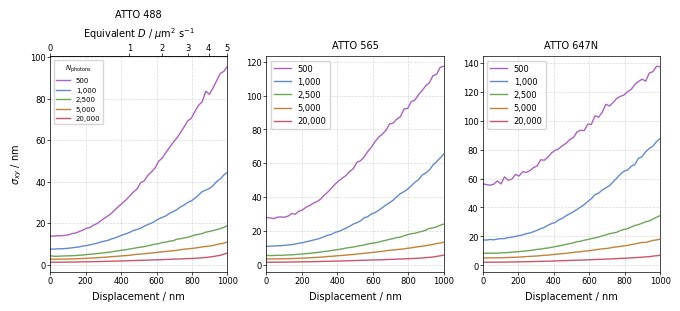

In [19]:
# ── Figure 2a: localisation precision σ_xy vs displacement — lines ───────────
# X = displacement (nm), Y = σ_xy (nm); one line per photon level.
# First panel: secondary x-axis showing equivalent D (µm² s⁻¹) at T = 50 ms.
metric = "sigma_xy"

ph_sel  = [500, 1000, 2500, 5000, 20000]
colors  = ["#cb566b", "#c1833b", "#6da659", "#648ace", "#ab62c0"][::-1]

T_exp_s = 0.05   # experimental exposure time (50 ms) used for D conversion
displacements_nm_axis = da_motion.coords["displacement_nm"].values

fig, axs = plotter.two_column_plot(nrows=1, ncols=len(dyes), width_ratios=np.ones(len(dyes)))
for i_c, dye in enumerate(dyes):
    ax = axs[i_c]
    Z = da_motion.isel(dye=i_c).sel(metric=metric).values  # (n_disp, n_photons)
    for val, ph in enumerate(ph_sel):
        ind = np.argmin(np.abs(n_photon_space - ph))
        ax = plotter.line_plot(ax, displacements_nm_axis, Z[:, ind],
                               color=colors[val], label=f'{ph:,}')
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    ax.set_ylabel(r"$\sigma_{xy}$ / nm" if i_c == 0 else "", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)
    ax.set_xlim([displacements_nm_axis[0], displacements_nm_axis[-1]])
    if i_c == 0:
        ax.legend(title=r"$N_\mathrm{photons}$", fontsize=fs - 2, title_fontsize=fs - 2)
        ax2 = ax.secondary_xaxis(
            "top",
            functions=(
                lambda d, T=T_exp_s: d**2 / (4 * T * 1e6),
                lambda D, T=T_exp_s: np.sqrt(np.maximum(D, 0) * 4 * T * 1e6),
            ),
        )
        ax2.set_xlabel(r"Equivalent $D$ / $\mu$m$^{2}$ s$^{-1}$", fontsize=fs)
        ax2.tick_params(labelsize=fs - 1)

plotter.save_or_show(fig, save_path=str(save_folder / "localisation_precision_lines.svg"))

INFO:src.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur/colour_precision_lines.svg


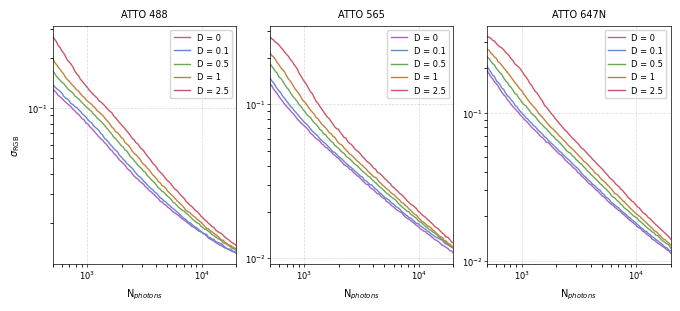

In [20]:
# ── Figure 2a: localisation precision σ_xy — lines ──────────────────────
# X = displacement (nm), Y = photon count (log), colour = σ_xy (nm, viridis).
# One panel per dye; shared colour scale across all three dyes.
metric     = "colour_dist"

colors = ["#cb566b",
"#c1833b",
"#6da659",
"#648ace",
"#ab62c0"][::-1]

data_m = da_motion.sel(metric=metric).values  # (n_dye, n_disp, n_ph)

fig, axs = plotter.two_column_plot(nrows=1, ncols=len(dyes), width_ratios=np.ones(len(dyes)))
for i_c, dye in enumerate(dyes):
    ax = axs[i_c]
    # da shape: (n_disp, n_photons); transpose → (n_photons, n_disp) for pcolormesh
    Z = da_motion.isel(dye=i_c).sel(metric=metric).values
    for val, D in enumerate(D_sel):
        ind = np.argmin(np.abs(displacements_diffusion - D))
        ax = plotter.line_plot(ax, n_photon_space, Z[ind, :], color=colors[val], label='D = '+str(D))
    ax.set_yscale("log")
    ax.set_xlabel(r'N$_{photons}$', fontsize=fs)
    ax.set_ylabel(r"$\sigma_{\mathrm{RGB}}$" if i_c == 0 else "", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)
    ax.set_xlim([np.min(n_photon_space), np.max(n_photon_space)])
    ax.set_xscale('log')
#fig.tight_layout(pad=0.4)
plotter.save_or_show(fig, save_path=str(save_folder / "colour_precision_lines.svg"))

## Bias Analysis

Bias = systematic offset of the **mean** fit from truth (distinct from precision/RMSE above).

- **Position bias** `bias_xy`: $\sqrt{(\bar\epsilon_x^2 + \bar\epsilon_y^2)/2}$ in nm, where $\bar\epsilon = \text{mean}(x_\text{fit} - x_0)$ across bootstraps.
- **Colour bias** `colour_bias`: Euclidean distance of the mean normalised fitted colour $\bar f_\text{fit} = \overline{A_\text{BGR}/\sum A}$ from the true BGR fraction $f_\text{true}$.

Both metrics use only valid localisations (positive $\sigma$, within image bounds).

In [23]:
from scipy.spatial.distance import cdist

# ── Build bias DataArray from raw HDF5 + groundtruth/input_params CSVs ────────
# bias_xy     : sqrt((mean_ex^2 + mean_ey^2) / 2)  in nm
# colour_bias : ||mean(A_BGR / sum) − true_BGR||   (normalised fraction space)
metrics_bias = ["bias_xy", "colour_bias"]

da_motion_bias = xr.DataArray(
    data=np.full(
        [len(dyes), len(velocities_nm_per_s), len(n_photon_space), len(metrics_bias)],
        np.nan,
    ),
    coords={
        "dye":            dyes,
        "displacement_nm": displacements_sweep_nm,
        "n_photons":      n_photon_space,
        "metric":         metrics_bias,
    },
    dims=["dye", "displacement_nm", "n_photons", "metric"],
)

for i_dye, dye in enumerate(dyes):
    dye_str = dye.replace("/", "-")
    for i_v, v_nm_s in enumerate(velocities_nm_per_s):
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"

        gt_files = sorted(glob.glob(str(save_folder / f"{flag}*{dye_str}*groundtruth*.csv")))
        ip_files = sorted(glob.glob(str(save_folder / f"{flag}*{dye_str}*input_parameters*.csv")))
        h5_path  = save_folder / f"{flag}LM_method_{dye_str}_rawresults.h5"

        if not gt_files or not ip_files or not h5_path.exists():
            continue

        gt    = pd.read_csv(gt_files[0])
        gt_px = np.vstack([gt["x0"].to_numpy() / pixel_size_nm,
                           gt["y0"].to_numpy() / pixel_size_nm]).T  # (n_bootstrap, 2) px

        dye_BGR = pd.read_csv(ip_files[0]).to_numpy()[0][-3:]
        colour_true = (dye_BGR / dye_BGR.sum()).reshape(1, 3)

        df_raw = pd.read_hdf(str(h5_path), key="data")

        for i_ph in range(len(n_photon_space)):
            subset = df_raw[df_raw["photon_level"] == i_ph]
            if len(subset) == 0:
                continue

            xc = subset["xc"].to_numpy()
            yc = subset["yc"].to_numpy()
            filt = (
                (xc >= 0) & (yc >= 0) &
                (subset["s_x"].to_numpy() > 0) &
                (subset["s_y"].to_numpy() > 0) &
                (xc <= image_dims) & (yc <= image_dims)
            )
            if filt.sum() < 2:
                continue

            ex = (xc[filt] - gt_px[filt, 0]) * pixel_size_nm
            ey = (yc[filt] - gt_px[filt, 1]) * pixel_size_nm
            bx, by = float(np.nanmean(ex)), float(np.nanmean(ey))
            da_motion_bias[i_dye, i_v, i_ph, 0] = np.sqrt((bx**2 + by**2) / 2)

            abgr = np.vstack([
                subset["A_B"].to_numpy()[filt],
                subset["A_G"].to_numpy()[filt],
                subset["A_R"].to_numpy()[filt],
            ]).T  # (n_valid, 3)
            row_sums = abgr.sum(axis=1, keepdims=True)
            with np.errstate(divide="ignore", invalid="ignore"):
                abgr_norm = np.where(row_sums > 0, abgr / row_sums, np.nan)
            mean_colour = np.nanmean(abgr_norm, axis=0, keepdims=True)
            da_motion_bias[i_dye, i_v, i_ph, 1] = float(
                cdist(mean_colour, colour_true)[0, 0]
            )

da_motion_bias.to_netcdf(str(save_folder / "motionblur_bias.nc"))
print(f"Bias DataArray: {da_motion_bias.shape}")
print(f"bias_xy  : {float(da_motion_bias.sel(metric='bias_xy').min()):.2f}–"
      f"{float(da_motion_bias.sel(metric='bias_xy').max()):.2f} nm")
print(f"col. bias: {float(da_motion_bias.sel(metric='colour_bias').min()):.4f}–"
      f"{float(da_motion_bias.sel(metric='colour_bias').max()):.4f}")

Bias DataArray: (3, 50, 100, 2)
bias_xy  : 0.00–9.00 nm
col. bias: 0.0018–0.1657


In [24]:
da_motion_bias

<xarray.DataArray (dye: 3, displacement_nm: 50, n_photons: 100, metric: 2)> Size: 240kB
array([[[[  9.25835688e-02,   7.03715597e-03],
         [  2.89680667e-02,   8.44435485e-03],
         [  5.66655967e-02,   1.01102407e-02],
         ..., 
         [  1.10937124e-03,   9.14608025e-03],
         [  1.38642393e-02,   9.19964253e-03],
         [  1.95663584e-02,   9.09625072e-03]],

        [[  4.20551347e-02,   6.04713887e-03],
         [  3.74882467e-02,   6.84895850e-03],
         [  1.61337791e-01,   7.10385427e-03],
         ..., 
         [  1.17817086e-02,   9.16995584e-03],
         [  2.24716707e-03,   9.07971280e-03],
         [  4.62939894e-03,   9.04726202e-03]],

        [[  1.44465838e-01,   7.60215506e-03],
         [  2.22384209e-01,   7.82986833e-03],
         [  1.28655364e-01,   9.23505527e-03],
         ..., 
...
         ..., 
         [  3.46214136e-01,   3.31475134e-03],
         [  4.50481266e-01,   3.34475199e-03],
         [  4.58795961e-01,   3.48686976e-03]],

        [[  9.00247816e+00,   1.61521451e-01],
         [  6.02415377e+00,   1.55051385e-01],
         [  7.88639332e+00,   1.48665740e-01],
         ..., 
         [  5.29300734e-01,   3.62808458e-03],
         [  5.43764859e-01,   3.48279748e-03],
         [  5.40071003e-01,   3.26473264e-03]],

        [[  7.16551126e+00,   1.65704196e-01],
         [  7.26742271e+00,   1.56068337e-01],
         [  8.02650225e+00,   1.52382027e-01],
         ..., 
         [  6.62879577e-01,   3.49236446e-03],
         [  6.10383970e-01,   3.53892032e-03],
         [  5.48090956e-01,   3.37867424e-03]]]])
Coordinates:
  * dye              (dye) <U9 108B 'ATTO 488' 'ATTO 565' 'ATTO 647N'
  * displacement_nm  (displacement_nm) float64 400B 0.0 20.41 ... 979.6 1e+03
  * n_photons        (n_photons) float64 800B 500.0 519.0 ... 1.927e+04 2e+04
  * metric           (metric) <U11 88B 'bias_xy' 'colour_bias'

INFO:src.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur/position_bias_lines.svg


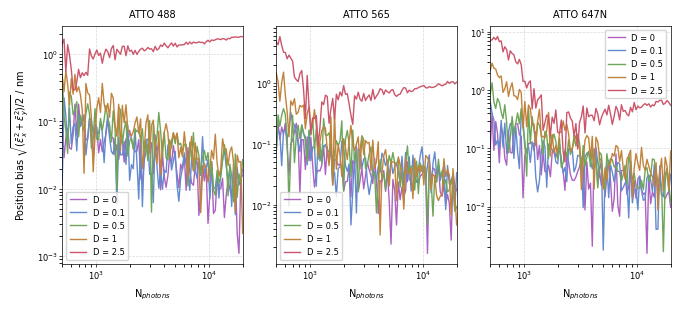

In [25]:
# ── Figure 7b: localisation precision σ_xy — lines ──────────────────────
# X = displacement (nm), Y = photon count (log), colour = σ_xy (nm, viridis).
# One panel per dye; shared colour scale across all three dyes.
metric     = "bias_xy"

colors = ["#cb566b",
"#c1833b",
"#6da659",
"#648ace",
"#ab62c0"][::-1]

data_m = da_motion_bias.sel(metric=metric).values  # (n_dye, n_disp, n_ph)

fig, axs = plotter.two_column_plot(nrows=1, ncols=len(dyes), width_ratios=np.ones(len(dyes)))
for i_c, dye in enumerate(dyes):
    ax = axs[i_c]
    # da shape: (n_disp, n_photons); transpose → (n_photons, n_disp) for pcolormesh
    Z = da_motion_bias.isel(dye=i_c).sel(metric=metric).values
    for val, D in enumerate(D_sel):
        ind = np.argmin(np.abs(displacements_diffusion - D))
        ax = plotter.line_plot(ax, n_photon_space, Z[ind, :], color=colors[val], label='D = '+str(D))
    ax.set_yscale("log")
    ax.set_xlabel(r'N$_{photons}$', fontsize=fs)
    ax.set_ylabel(r"Position bias $\sqrt{(\bar{\epsilon}_x^2+\bar{\epsilon}_y^2)/2}$ / nm" if i_c == 0 else "", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)
    ax.set_xlim([np.min(n_photon_space), np.max(n_photon_space)])
    ax.set_xscale('log')
#fig.tight_layout(pad=0.4)
plotter.save_or_show(fig, save_path=str(save_folder / "position_bias_lines.svg"))

INFO:src.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260623_MotionBlur/colour_bias_lines.svg


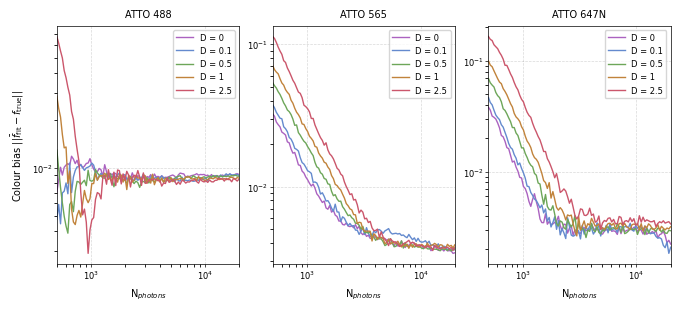

In [26]:
# ── Figure 7b: localisation precision σ_xy — lines ──────────────────────
# X = displacement (nm), Y = photon count (log), colour = σ_xy (nm, viridis).
# One panel per dye; shared colour scale across all three dyes.
metric     = "colour_bias"

colors = ["#cb566b",
"#c1833b",
"#6da659",
"#648ace",
"#ab62c0"][::-1]

data_m = da_motion_bias.sel(metric=metric).values  # (n_dye, n_disp, n_ph)

fig, axs = plotter.two_column_plot(nrows=1, ncols=len(dyes), width_ratios=np.ones(len(dyes)))
for i_c, dye in enumerate(dyes):
    ax = axs[i_c]
    # da shape: (n_disp, n_photons); transpose → (n_photons, n_disp) for pcolormesh
    Z = da_motion_bias.isel(dye=i_c).sel(metric=metric).values
    for val, D in enumerate(D_sel):
        ind = np.argmin(np.abs(displacements_diffusion - D))
        ax = plotter.line_plot(ax, n_photon_space, Z[ind, :], color=colors[val], label='D = '+str(D))
    ax.set_yscale("log")
    ax.set_xlabel(r'N$_{photons}$', fontsize=fs)
    ax.set_ylabel(r"Colour bias $||\bar{f}_{\mathrm{fit}} - f_{\mathrm{true}}||$" if i_c == 0 else "", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.tick_params(labelsize=fs - 1)
    ax.set_xlim([np.min(n_photon_space), np.max(n_photon_space)])
    ax.set_xscale('log')
#fig.tight_layout(pad=0.4)
plotter.save_or_show(fig, save_path=str(save_folder / "colour_bias_lines.svg"))

## Comparative Degradation Surfaces

How much worse does each metric get relative to the **zero-displacement (no motion blur) baseline**?

**Precision metrics** (`sigma_xy`, `colour_dist`, `ellipticity`) are shown as a **fold ratio**
`metric(d) / metric(d = 0)`: value 1 = identical to no blur, value 2 = twice as bad.
The baseline is always positive so the ratio is well-defined.

**Bias metrics** (`bias_xy`, `colour_bias`) are shown as the **absolute increase**
`metric(d) − metric(d = 0)` because the zero-displacement bias is near zero for a well-calibrated
fitter, making a fold ratio numerically unstable. The increase answers directly: *how much extra
systematic error does motion introduce?*

Colourmap: `plasma` (dark purple = no worsening, bright yellow = maximum degradation).
Colour scale clipped at the 99th percentile to suppress isolated outliers.

In [ ]:
# ── Load xarrays from disk ────────────────────────────────────────────────────
da_motion      = xr.open_dataarray(str(save_folder / "motionblur_sweep.nc"))
da_motion_bias = xr.open_dataarray(str(save_folder / "motionblur_bias.nc"))

dyes                   = list(da_motion.coords["dye"].values)
dye_labels             = {d: d for d in dyes}
displacements_sweep_nm = da_motion.coords["displacement_nm"].values
n_photon_space         = da_motion.coords["n_photons"].values
fs = plotter.config.font_size

print(f"Loaded da_motion      {dict(da_motion.sizes)}")
print(f"Loaded da_motion_bias {dict(da_motion_bias.sizes)}")

In [ ]:
# ── Figure 8: precision metrics — fold degradation vs zero-displacement baseline ──
# ratio = metric(d) / metric(d=0); ratio = 1 means identical to no blur.
# xarray broadcasts the (dye, n_photons, metric) baseline across displacement_nm.

metric_list = ["sigma_xy",                   "colour_dist",                         "ellipticity"]
cbar_lbls   = [r"$\sigma_{xy}$ fold × no blur",
               r"$\sigma_{\rm colour}$ fold × no blur",
               r"Ellipticity fold × no blur"]

baseline_p = da_motion.isel(displacement_nm=0)                    # (dye, n_photons, metric)
# Guard against zero baseline (shouldn't occur for precision metrics, but clip for safety)
ratio_motion = da_motion / baseline_p.where(baseline_p > 1e-10)   # (dye, disp, n_photons, metric)

fig, axs = plt.subplots(
    nrows=len(metric_list), ncols=len(dyes),
    figsize=(6.69, 2.5 * len(metric_list)),
    squeeze=False,
)
for i_m, (metric, cbar_lbl) in enumerate(zip(metric_list, cbar_lbls)):
    data_row = ratio_motion.sel(metric=metric).values                  # (n_dye, n_disp, n_ph)
    vmin = 1.0
    vmax = float(np.nanpercentile(data_row, 99))
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i_c, dye in enumerate(dyes):
        ax = axs[i_m, i_c]
        Z = ratio_motion.isel(dye=i_c).sel(metric=metric).values       # (n_disp, n_ph)
        ax.pcolormesh(displacements_sweep_nm, n_photon_space, Z.T,
                      cmap="plasma", shading="auto", norm=norm)
        ax.set_yscale("log")
        ax.set_xlabel("Displacement / nm", fontsize=fs)
        ax.set_ylabel("Photons" if i_c == 0 else "", fontsize=fs - 1)
        if i_m == 0:
            ax.set_title(dye_labels[dye], fontsize=fs)
        ax.tick_params(labelsize=fs - 1)

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap="plasma"),
        ax=axs[i_m, :].tolist(),
        label=cbar_lbl, shrink=0.85, aspect=20, pad=0.02,
    )

plotter.save_or_show(
    fig, save_path=str(save_folder / "precision_fold_degradation_surface.svg")
)

In [ ]:
# ── Figure 9: bias metrics — absolute increase vs zero-displacement baseline ───
# increase = metric(d) − metric(d=0).
# Fold ratio avoided here because zero-displacement bias is near 0 nm / 0 a.u.,
# making division numerically unstable.  Absolute increase answers directly:
# "how much extra systematic error does motion blur introduce?"

metric_list_b = ["bias_xy",                                          "colour_bias"]
cbar_lbls_b   = [r"Extra pos. bias $\Delta\sqrt{(\bar\epsilon_x^2+\bar\epsilon_y^2)/2}$ / nm",
                 r"Extra colour bias $\Delta||\bar{f}_{\rm fit}-f_{\rm true}||$"]

baseline_b  = da_motion_bias.isel(displacement_nm=0)                 # (dye, n_photons, metric)
increase_b  = da_motion_bias - baseline_b                             # xarray broadcasts

fig, axs = plt.subplots(
    nrows=len(metric_list_b), ncols=len(dyes),
    figsize=(6.69, 2.5 * len(metric_list_b)),
    squeeze=False,
)
for i_m, (metric, cbar_lbl) in enumerate(zip(metric_list_b, cbar_lbls_b)):
    data_row = increase_b.sel(metric=metric).values                    # (n_dye, n_disp, n_ph)
    vmin = 0.0
    vmax = float(np.nanpercentile(data_row, 99))
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i_c, dye in enumerate(dyes):
        ax = axs[i_m, i_c]
        Z = increase_b.isel(dye=i_c).sel(metric=metric).values         # (n_disp, n_ph)
        ax.pcolormesh(displacements_sweep_nm, n_photon_space, Z.T,
                      cmap="plasma", shading="auto", norm=norm)
        ax.set_yscale("log")
        ax.set_xlabel("Displacement / nm", fontsize=fs)
        ax.set_ylabel("Photons" if i_c == 0 else "", fontsize=fs - 1)
        if i_m == 0:
            ax.set_title(dye_labels[dye], fontsize=fs)
        ax.tick_params(labelsize=fs - 1)

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap="plasma"),
        ax=axs[i_m, :].tolist(),
        label=cbar_lbl, shrink=0.85, aspect=20, pad=0.02,
    )

plotter.save_or_show(
    fig, save_path=str(save_folder / "bias_absolute_increase_surface.svg")
)